## This is the code for generating the Influence Score vs. Loss Plot.

By default, if you play this file directly, it will generate the IF and TracIn score vs Samples Loss plot with respect to our experiment result.

**Main Guideline**:  
Read in the Influence lists and Loss lists -> Merge the two lists to have both influence score and loss for each sample -> Plot the influence score vs the Sample Loss -> Add a regression Line inside the plot

**Format**:  
**Input** The Influence lists and loss lists that you read in.  
**Output**  The influence score vs Loss Plot with regression line inserted.

You don't need to change anything else if you only want to produce the Influence Score vs Sample Loss plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

Import Area

In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

1. We first read in the Influence Score lists and Loss list.

In [20]:
df_IF = pd.read_csv("Diamonds_IF_Train_Set_1.csv")
df_TC = pd.read_csv("Diamonds_TC_Train_Set_1.csv")
df_loss = pd.read_csv("Diamonds_Train_Loss_Train_Set_1.csv")

2. Then the two lists will be merged on the same training sample.

In [21]:
df = pd.merge(df_IF, df_loss, on="Train_ID", how="inner")
print(df)

       Train_ID     Score       Loss
0         20093  0.002421   0.132611
1          4546  0.002387   0.144705
2          4479  0.002381   0.173473
3         52702  0.002376   0.129874
4          8572  0.002314   0.185565
...         ...       ...        ...
53435     33840 -0.196920  31.985361
53436     40576 -0.197196  29.950096
53437     33644 -0.210633  31.140001
53438     12222 -0.212700  29.715176
53439     52314 -0.223952  57.831642

[53440 rows x 3 columns]


3. Some basic statistics are given here but not really necessary. Just to have a brief look of the data

In [22]:
scores = df["Score"]

print("=== Basic Statistics ===")
print(f"Mean: {np.mean(scores):.6f}")
print(f"Median: {np.median(scores):.6f}")
print(f"Std: {np.std(scores):.6f}")
print(f"Min: {np.min(scores):.6f}")
print(f"Max: {np.max(scores):.6f}")

=== Basic Statistics ===
Mean: 0.000048
Median: 0.000004
Std: 0.002426
Min: -0.223952
Max: 0.002421


In [23]:
total = len(scores)

num_positive = np.sum(scores > 0)
num_negative = np.sum(scores < 0)

print("\n=== Sign Distribution ===")
print(f"Positive: {num_positive} ({num_positive/total*100:.2f}%)")
print(f"Negative: {num_negative} ({num_negative/total*100:.2f}%)")


=== Sign Distribution ===
Positive: 52084 (97.46%)
Negative: 1355 (2.54%)


In [24]:
neg = scores[scores < 0]
pos = scores[scores > 0]

print("Mean |neg|:", np.mean(np.abs(neg)))
print("Mean |pos|:", np.mean(np.abs(pos)))

Mean |neg|: 0.003714612161839856
Mean |pos|: 0.00014631589322723927


4. Main plot is produced here, where we plot the Influence Score to the corresponding sample loss.

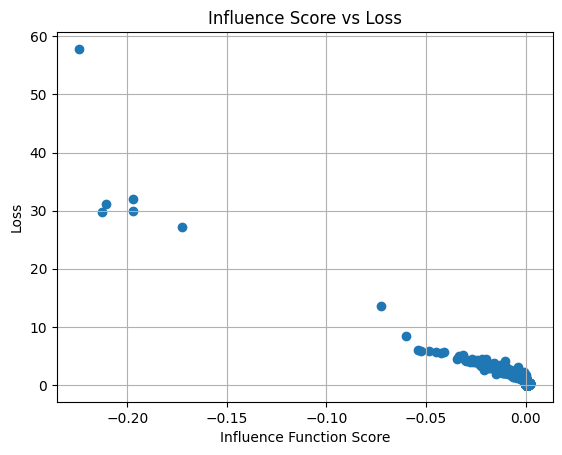

In [25]:
import matplotlib.pyplot as plt

plt.scatter(df["Score"], df["Loss"])
plt.xlabel("Influence Function Score")
plt.ylabel("Loss")
plt.title("Influence Score vs Loss")
plt.grid(True)
plt.show()

5. Then, the regression line for the two data are fit here

In [26]:
X = df["Score"].values.reshape(-1, 1)
y = df["Loss"].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Slope: -170.94924808141604
Intercept: 0.06979252401575786
R^2: 0.8073509148494902


6. We finally plot the regression line inside the original plot.

In [27]:
# plt.scatter(X, y, alpha=0.6, label="Data")
# plt.plot(X, y_pred, linewidth=2, label="Regression Line",color="red")

# plt.xlabel("Influence Function Score")
# plt.ylabel("Loss")
# plt.title("Influence vs Loss with Regression Fit")
# plt.legend()
# plt.grid(True)
# plt.savefig(
#     "Outliers_Diamonds_FOIF.png",
#     dpi=600,
#     bbox_inches="tight"
# )

# plt.show()

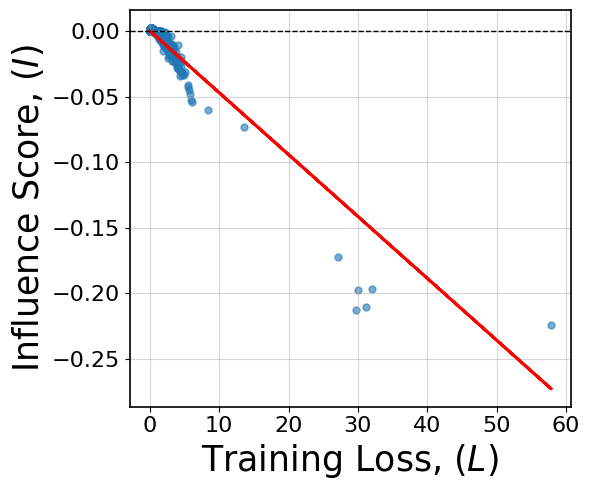

In [28]:
x_loss = y.reshape(-1, 1)          # x-axis: Training loss
y_infl = X.reshape(-1, 1)          # y-axis: Aggregated influence score

reg = LinearRegression()
reg.fit(x_loss, y_infl)
y_pred = reg.predict(x_loss)

plt.figure(figsize=(6, 5))

plt.scatter(x_loss, y_infl, alpha=0.6, s=25)
plt.plot(x_loss, y_pred, linewidth=2, color="red")

# horizontal zero line
plt.axhline(y=0, color="black", linewidth=1, linestyle="--")

# labels with larger font
plt.xlabel("Training Loss, ($L$)", fontsize=25)
plt.ylabel("Influence Score, ($I$)", fontsize=25)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


# grid
plt.grid(True, alpha=0.5)

# add border / box
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

# remove title and legend
# plt.title(...)
# plt.legend()

plt.savefig(
    "Outliers_Diamonds_IF_large.png",
    dpi=600,
    bbox_inches="tight"
)


plt.tight_layout()
plt.show()

7. Same procedure happens in the following for the TracIn score and Loss.

In [29]:
df_TCLOSS = pd.merge(df_TC, df_loss, on="Train_ID", how="inner")
print(df_TCLOSS)

       Train_ID     Score       Loss
0         22575  0.000021   2.460651
1         38026  0.000019   2.232249
2         18324  0.000019   1.770592
3         26913  0.000018   1.451945
4         39086  0.000018   1.235376
...         ...       ...        ...
53435      6309 -0.000096  27.165499
53436     12222 -0.000104  29.715176
53437     40576 -0.000106  29.950096
53438     33644 -0.000109  31.140001
53439     33840 -0.000113  31.985361

[53440 rows x 3 columns]


In [30]:
scores = df_TCLOSS["Score"]

print("=== Basic Statistics ===")
print(f"Mean: {np.mean(scores):.6f}")
print(f"Median: {np.median(scores):.6f}")
print(f"Std: {np.std(scores):.6f}")
print(f"Min: {np.min(scores):.6f}")
print(f"Max: {np.max(scores):.6f}")

=== Basic Statistics ===
Mean: 0.000000
Median: 0.000000
Std: 0.000002
Min: -0.000113
Max: 0.000021


In [31]:
total = len(scores)

num_positive = np.sum(scores > 0)
num_negative = np.sum(scores < 0)

print("\n=== Sign Distribution ===")
print(f"Positive: {num_positive} ({num_positive/total*100:.2f}%)")
print(f"Negative: {num_negative} ({num_negative/total*100:.2f}%)")


=== Sign Distribution ===
Positive: 26726 (50.01%)
Negative: 26713 (49.99%)


In [32]:
neg = scores[scores < 0]
pos = scores[scores > 0]

print("Mean |neg|:", np.mean(np.abs(neg)))
print("Mean |pos|:", np.mean(np.abs(pos)))

Mean |neg|: 3.300701448099287e-07
Mean |pos|: 5.52909338236292e-07


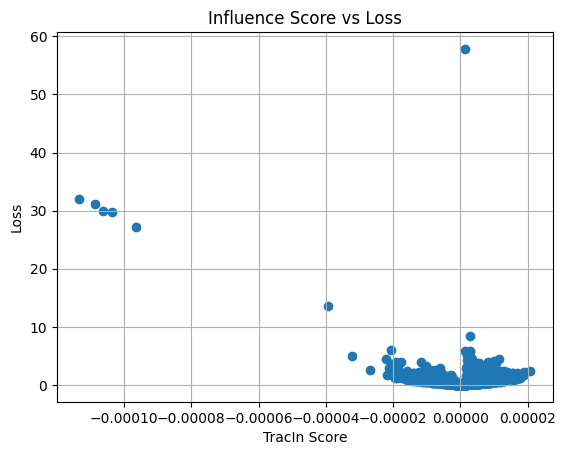

In [33]:
import matplotlib.pyplot as plt

plt.scatter(df_TCLOSS["Score"], df_TCLOSS["Loss"])
plt.xlabel("TracIn Score")
plt.ylabel("Loss")
plt.title("Influence Score vs Loss")
plt.grid(True)
plt.show()

In [34]:
from sklearn.linear_model import LinearRegression
import numpy as np
X = df_TCLOSS["Score"].values.reshape(-1, 1)
y = df_TCLOSS["Loss"].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Slope: -63317.46047107425
Intercept: 0.06857710669672751
R^2: 0.06864988631889757


In [35]:
# plt.scatter(X, y, alpha=0.6, label="Data")
# plt.plot(X, y_pred, linewidth=2, label="Regression Line",color="red")

# plt.xlabel("TracIn Score")
# plt.ylabel("Loss")
# plt.title("Influence vs Loss with Regression Fit")
# plt.legend()
# plt.grid(True)
# plt.savefig(
#     "Outliers_Diamonds_TC.png",
#     dpi=600,
#     bbox_inches="tight"
# )
# plt.show()

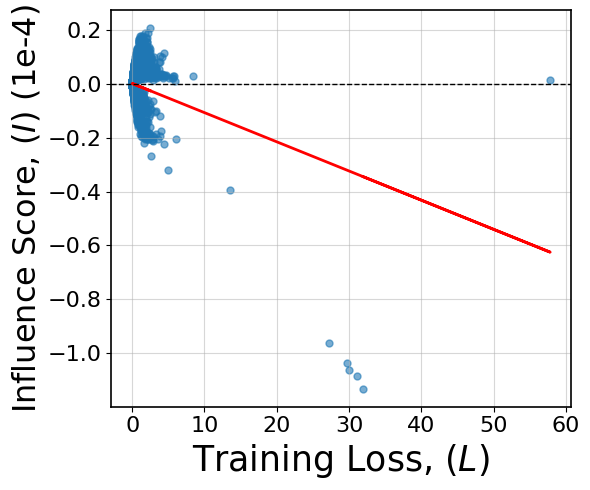

In [37]:
x_loss = y.reshape(-1, 1)          # x-axis: Training loss
y_infl = X.reshape(-1, 1)          # y-axis: Aggregated influence score

reg = LinearRegression()
reg.fit(x_loss, y_infl)
y_pred = reg.predict(x_loss)

plt.figure(figsize=(6, 5))

plt.scatter(x_loss, y_infl, alpha=0.6, s=25)
plt.plot(x_loss, y_pred, linewidth=2, color="red")

# horizontal zero line
plt.axhline(y=0, color="black", linewidth=1, linestyle="--")

# labels with larger font
plt.xlabel(r"Training Loss, ($L$)", fontsize=25)
plt.ylabel(r"Influence Score, ($I$) (1e-4)", fontsize=23)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


# grid
plt.grid(True, alpha=0.5)

# add border / box
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")


# from matplotlib.ticker import FuncFormatter

# def sci_formatter(y, pos):
#     if abs(y) < 1e-12:
#         return "0"
#     exponent = -5
#     coeff = y / 10**exponent
#     return rf"${coeff:.0f}\cdot10^{{{exponent}}}$"

# ax.yaxis.set_major_formatter(FuncFormatter(sci_formatter))

#ax.ticklabel_format(axis='y', style='plain')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.yaxis.get_offset_text().set_visible(False)

# remove title and legend
# plt.title(...)
# plt.legend()

plt.savefig(
    "Outliers_Diamonds_TC_Large.png",
    dpi=600,
    bbox_inches="tight"
)


plt.tight_layout()
plt.show()